# 正样本数据预处理
基于yellowbrick对正样本查询集进行语义聚类处理

In [3]:
import os
import sys
import yaml
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from sklearn.cluster import KMeans

# 向上两级到项目根目录
PROJECT_ROOT = Path(os.path.abspath("")).resolve()
while not (PROJECT_ROOT / "configs").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.retriever.Base import create_embedder

In [4]:
# ===========================================================
# Load the Jina code embedding model from config
# ===========================================================
with open(f"{PROJECT_ROOT}/configs/models/jina-code-embeddings-0.5b.yml", "r") as f:
    jina_config = yaml.safe_load(f)

jina_embedder = create_embedder(jina_config)
device = jina_config.get("device", "cuda")

# ===========================================================
# Load the dataset
# ===========================================================
# 加载并处理正样本查询集
df = pd.read_json(f"{PROJECT_ROOT}/data/bfp/white/raw/CWE20_RELEVANCE_0.75_TOP_10.json", lines=False)
df

设备池预筛选排除 cuda:1（nvidia-smi 判定为不健康）
设备池预筛选排除 cuda:2（nvidia-smi 判定为不健康）
设备池预筛选排除 cuda:3（nvidia-smi 判定为不健康）


,id,source,language,buggy_code,fixed_code,retrieval_results
0,135,CoCoNut,C,static int vp3_decode_init(AVCodecContext *avc...,static int vp3_decode_init(AVCodecContext *avc...,"[{'doc_id': '178320', 'chunk_id': 0, 'cluster_..."
1,153,CoCoNut,C,static int mpeg_decode_slice(AVCodecContext *a...,static int mpeg_decode_slice(AVCodecContext *a...,"[{'doc_id': '187969', 'chunk_id': 0, 'cluster_..."
2,295,CoCoNut,C,"static void gunzip(void *dst, int dstlen, unsi...","static void gunzip(void *dst, int dstlen, unsi...","[{'doc_id': '178225', 'chunk_id': 0, 'cluster_..."
3,316,CoCoNut,C,"sys_shmat(p, v, retval)\tstruct proc *p;\tvoid...","sys_shmat(p, v, retval)\tstruct proc *p;\tvoid...","[{'doc_id': '181551', 'chunk_id': 0, 'cluster_..."
4,324,CoCoNut,C,static struct mm_struct * mm_init(struct mm_st...,static struct mm_struct * mm_init(struct mm_st...,"[{'doc_id': '9407', 'chunk_id': 0, 'cluster_id..."
...,...,...,...,...,...,...
398,46334,CoCoNut,C,static int sgl_map_user_pages(struct scatterli...,static int sgl_map_user_pages(struct scatterli...,"[{'doc_id': '215342', 'chunk_id': 0, 'cluster_..."
399,46343,CoCoNut,C,"int BN_mod_exp_recp(BIGNUM *r, const BIGNUM *a...","int BN_mod_exp_recp(BIGNUM *r, const BIGNUM *a...","[{'doc_id': '216574', 'chunk_id': 0, 'cluster_..."
400,46346,CoCoNut,C,static int standard_decode_picture_primary_hea...,static int standard_decode_picture_primary_hea...,"[{'doc_id': '182363', 'chunk_id': 0, 'cluster_..."
401,46373,CoCoNut,C,"main(argc, argv, envp)\tint argc;\tchar **argv...","main(argc, argv, envp)\tint argc;\tchar **argv...","[{'doc_id': '183208', 'chunk_id': 0, 'cluster_..."


In [5]:
# 按照buggy_code对df内的数据进行去重
before = len(df)
df = df.drop_duplicates(subset=['buggy_code'], keep='first').reset_index(drop=True)
after = len(df)
print(f"按 buggy_code 去重: {before} -> {after} (移除 {before - after})")
df

按 buggy_code 去重: 403 -> 403 (移除 0)


,id,source,language,buggy_code,fixed_code,retrieval_results
0,135,CoCoNut,C,static int vp3_decode_init(AVCodecContext *avc...,static int vp3_decode_init(AVCodecContext *avc...,"[{'doc_id': '178320', 'chunk_id': 0, 'cluster_..."
1,153,CoCoNut,C,static int mpeg_decode_slice(AVCodecContext *a...,static int mpeg_decode_slice(AVCodecContext *a...,"[{'doc_id': '187969', 'chunk_id': 0, 'cluster_..."
2,295,CoCoNut,C,"static void gunzip(void *dst, int dstlen, unsi...","static void gunzip(void *dst, int dstlen, unsi...","[{'doc_id': '178225', 'chunk_id': 0, 'cluster_..."
3,316,CoCoNut,C,"sys_shmat(p, v, retval)\tstruct proc *p;\tvoid...","sys_shmat(p, v, retval)\tstruct proc *p;\tvoid...","[{'doc_id': '181551', 'chunk_id': 0, 'cluster_..."
4,324,CoCoNut,C,static struct mm_struct * mm_init(struct mm_st...,static struct mm_struct * mm_init(struct mm_st...,"[{'doc_id': '9407', 'chunk_id': 0, 'cluster_id..."
...,...,...,...,...,...,...
398,46334,CoCoNut,C,static int sgl_map_user_pages(struct scatterli...,static int sgl_map_user_pages(struct scatterli...,"[{'doc_id': '215342', 'chunk_id': 0, 'cluster_..."
399,46343,CoCoNut,C,"int BN_mod_exp_recp(BIGNUM *r, const BIGNUM *a...","int BN_mod_exp_recp(BIGNUM *r, const BIGNUM *a...","[{'doc_id': '216574', 'chunk_id': 0, 'cluster_..."
400,46346,CoCoNut,C,static int standard_decode_picture_primary_hea...,static int standard_decode_picture_primary_hea...,"[{'doc_id': '182363', 'chunk_id': 0, 'cluster_..."
401,46373,CoCoNut,C,"main(argc, argv, envp)\tint argc;\tchar **argv...","main(argc, argv, envp)\tint argc;\tchar **argv...","[{'doc_id': '183208', 'chunk_id': 0, 'cluster_..."


In [6]:
# 一次性传入全量代码列表，由 Jina 内部按 batch_size 分批编码
all_codes = df['buggy_code'].astype(str).tolist()

encoded_code_vectors = jina_embedder.embed_documents(all_codes)
encoded_code_vectors = np.asarray(encoded_code_vectors)

# 建立 idx -> 向量的映射（与 df 行顺序一致）
index_to_vector_map = {int(idx_val): encoded_code_vectors[i] for i, idx_val in enumerate(df['id'])}
print("encoded_code_vectors shape:", encoded_code_vectors.shape)

Batches: 100%|██████████| 403/403 [00:31<00:00, 12.77it/s]

encoded_code_vectors shape: (403, 896)


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

肘点法推荐的最佳簇数: 6


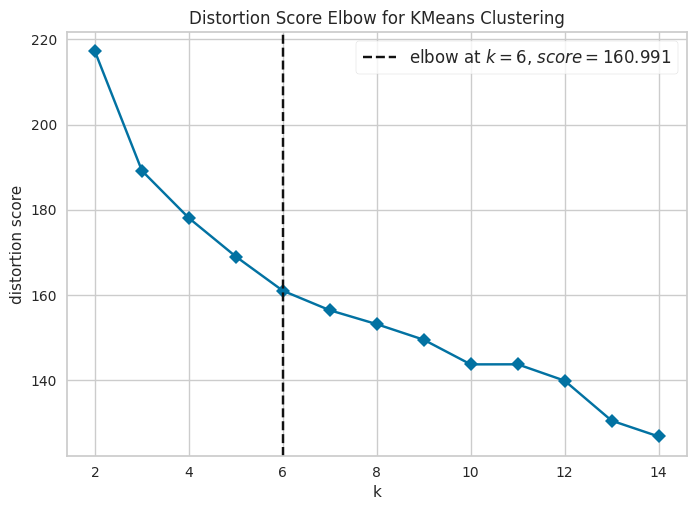


聚类完成！已将 403 条数据分为 6 个簇
各簇样本数分布:
cluster_id
0     65
1    110
2     40
3     55
4     71
5     62
Name: count, dtype: int64


In [7]:
# ===========================================================
# 使用 Yellowbrick 肘点法自动选择最佳簇数并进行 KMeans 聚类
# ===========================================================
from yellowbrick.cluster import KElbowVisualizer

# 将 tensor 转回 numpy 用于聚类
X = encoded_code_vectors

# 使用肘点法寻找最佳簇数（范围 2-15）
model = KMeans(random_state=42, n_init="auto")
visualizer = KElbowVisualizer(model, k=(2, 15), timings=False, force_model=True) # 注意：force_model=True 是必需的，用于接受未拟合的 KMeans 实例
visualizer.fit(X)

# 获取最佳簇数（若无法检测到肘点，默认使用 5）
optimal_k = visualizer.elbow_value_
if optimal_k is None:
    optimal_k = 5
    print(f"未检测到明显肘点，使用默认簇数: {optimal_k}")
else:
    print(f"肘点法推荐的最佳簇数: {optimal_k}")

# 显示肘点图
visualizer.show()

# 使用最佳簇数进行 KMeans 聚类
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(X)

# 将聚类标签添加到 dataframe
df['cluster_id'] = cluster_labels
print(f"\n聚类完成！已将 {len(df)} 条数据分为 {optimal_k} 个簇")
print(f"各簇样本数分布:")
print(df['cluster_id'].value_counts().sort_index())


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

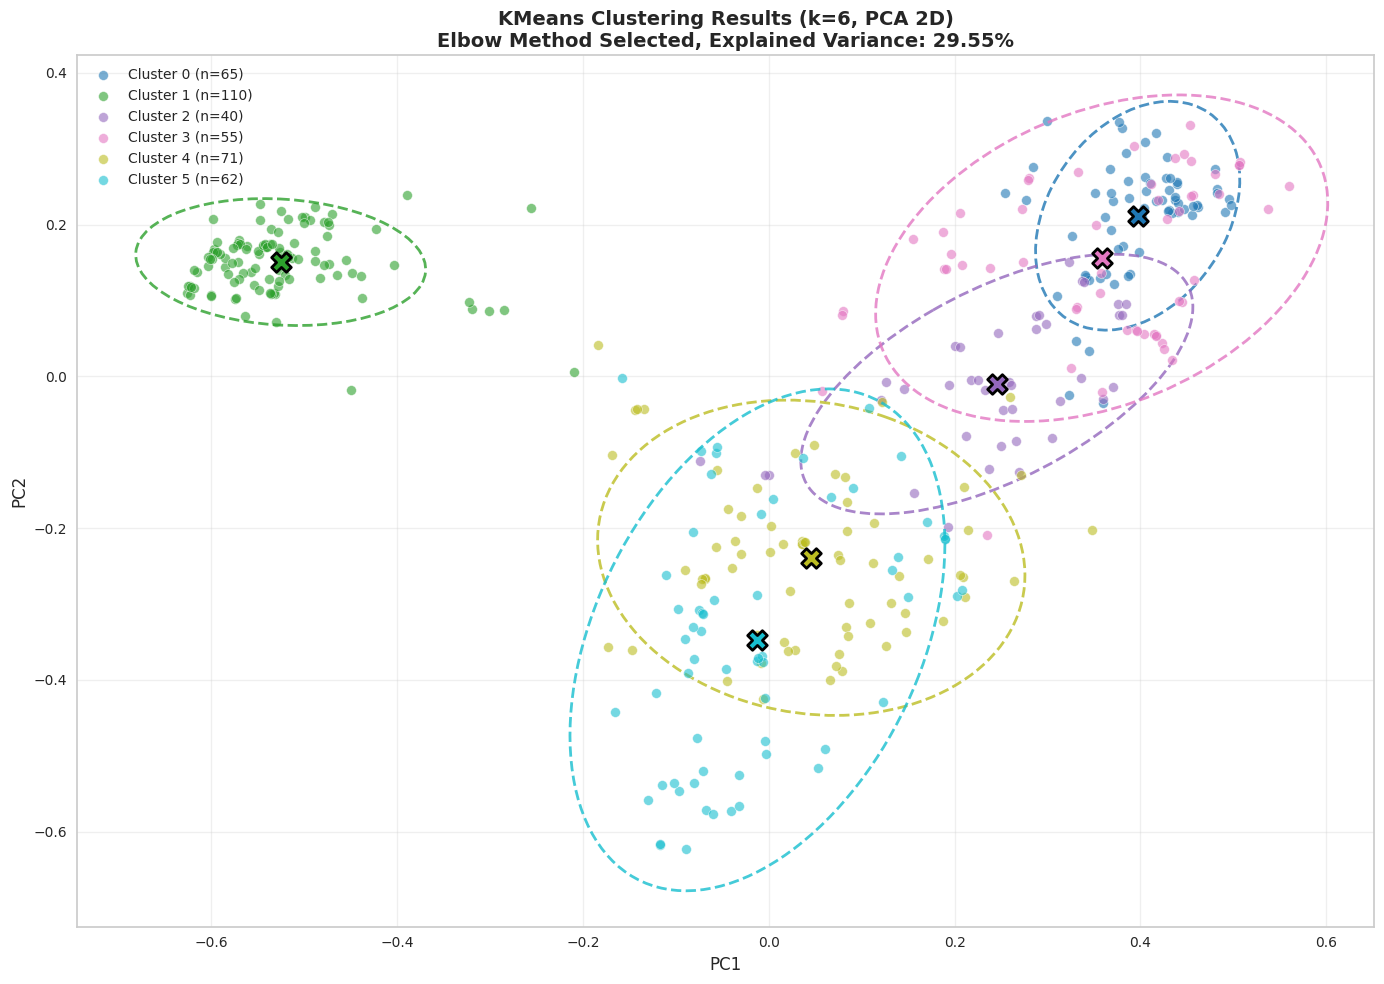


PCA 解释方差比例: PC1=20.94%, PC2=8.61%
总解释方差: 29.55%


'\noutput_path = PROJECT_ROOT / "data/bfp/white/clustered/CWE20_RELEVANCE_0.75_TOP_10_clustered.json"\noutput_path.parent.mkdir(parents=True, exist_ok=True)\n\n# 保存带聚类标签的结果\ndf.to_json(output_path, orient=\'records\', indent=2, force_ascii=False)\nprint(f"\n聚类结果已保存至: {output_path}")\n\n# 显示各簇统计信息\nprint("\n=== 各簇统计信息 ===")\nfor cid in sorted(df[\'cluster_id\'].unique()):\n    sample_count = len(df[df[\'cluster_id\'] == cid])\n    sample_id = df[df[\'cluster_id\'] == cid].iloc[0][\'id\']\n    print(f"Cluster {cid}: {sample_count} 条样本 (示例 ID: {sample_id})")\n'

In [8]:
# ===========================================================
# 可视化聚类结果（使用 PCA 降维到 2D）
# ===========================================================
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import numpy as np

# 使用 PCA 将高维向量降维到 2D 用于可视化
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

# 创建图形
fig, ax = plt.subplots(figsize=(14, 10))

# 获取聚类中心和标签
centers = kmeans.cluster_centers_
centers_2d = pca.transform(centers)
unique_labels = sorted(df['cluster_id'].unique())

# 使用高对比度颜色
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

# 绘制每个簇的数据点和范围
for i, cluster_id in enumerate(unique_labels):
    # 获取该簇的所有点
    mask = df['cluster_id'] == cluster_id
    cluster_points = X_2d[mask]
    
    # 绘制散点
    ax.scatter(
        cluster_points[:, 0], 
        cluster_points[:, 1],
        c=[colors[i]], 
        label=f'Cluster {cluster_id} (n={len(cluster_points)})',
        alpha=0.6,
        s=50,
        edgecolors='white',
        linewidth=0.5
    )
    
    # 绘制聚类中心
    ax.scatter(
        centers_2d[i, 0], 
        centers_2d[i, 1],
        c=[colors[i]],
        marker='X',
        s=200,
        edgecolors='black',
        linewidth=2,
        zorder=5
    )
    
    # 计算并绘制簇的椭圆边界（95% 置信区间）
    if len(cluster_points) > 2:
        # 计算均值和协方差
        mean = np.mean(cluster_points, axis=0)
        cov = np.cov(cluster_points.T)
        
        # 计算椭圆参数
        eigenvalues, eigenvectors = np.linalg.eigh(cov)
        order = eigenvalues.argsort()[::-1]
        eigenvalues = eigenvalues[order]
        eigenvectors = eigenvectors[:, order]
        
        # 椭圆角度和宽高
        angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
        width, height = 2 * np.sqrt(eigenvalues) * 2  # 2 sigma ~ 95%
        
        # 绘制椭圆
        ellipse = Ellipse(
            xy=mean,
            width=width,
            height=height,
            angle=angle,
            edgecolor=colors[i],
            facecolor='none',
            linewidth=2,
            linestyle='--',
            alpha=0.8
        )
        ax.add_patch(ellipse)

ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title(
    f'KMeans Clustering Results (k={optimal_k}, PCA 2D)\n'
    f'Elbow Method Selected, Explained Variance: {pca.explained_variance_ratio_.sum():.2%}',
    fontsize=14,
    fontweight='bold'
)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPCA 解释方差比例: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")
print(f"总解释方差: {pca.explained_variance_ratio_.sum():.2%}")

# ===========================================================
# 保存聚类结果
# ===========================================================
"""
output_path = PROJECT_ROOT / "data/bfp/white/clustered/CWE20_RELEVANCE_0.75_TOP_10_clustered.json"
output_path.parent.mkdir(parents=True, exist_ok=True)

# 保存带聚类标签的结果
df.to_json(output_path, orient='records', indent=2, force_ascii=False)
print(f"\n聚类结果已保存至: {output_path}")

# 显示各簇统计信息
print("\n=== 各簇统计信息 ===")
for cid in sorted(df['cluster_id'].unique()):
    sample_count = len(df[df['cluster_id'] == cid])
    sample_id = df[df['cluster_id'] == cid].iloc[0]['id']
    print(f"Cluster {cid}: {sample_count} 条样本 (示例 ID: {sample_id})")
"""


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

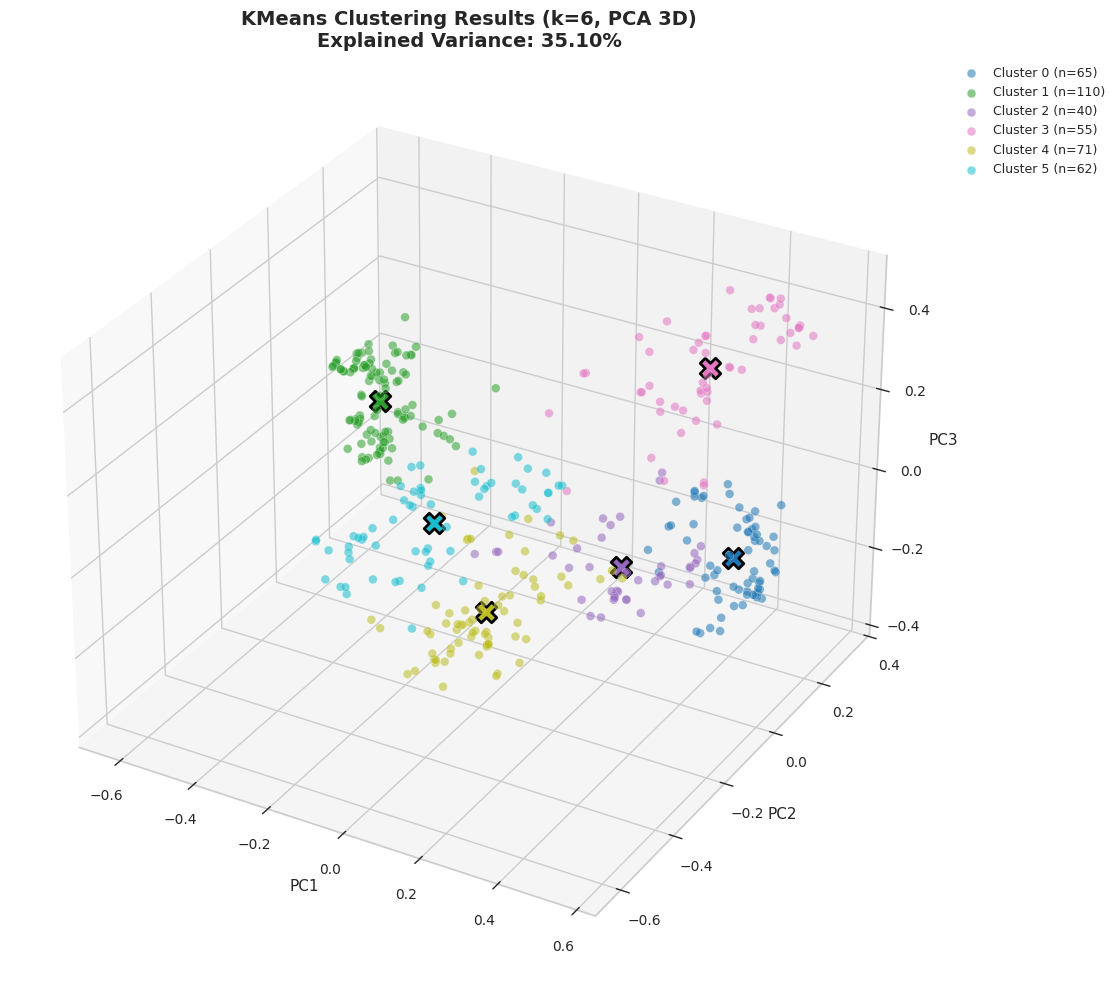


PCA(3D) 解释方差: PC1=20.94%, PC2=8.61%, PC3=5.55%
累计解释方差: 35.10%


In [9]:
# ===========================================================
# 可视化聚类结果（使用 PCA 降维到 3D）
# ===========================================================
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — 注册 3d 投影

# 独立拟合 3 个主成分（与上方 2D 的 PCA 互不干扰，便于分别复现）
pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X)

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

centers_3d = pca_3d.transform(kmeans.cluster_centers_)
unique_labels = sorted(df["cluster_id"].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for i, cluster_id in enumerate(unique_labels):
    mask = df["cluster_id"] == cluster_id
    cluster_points = X_3d[mask]
    ax.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        cluster_points[:, 2],
        c=[colors[i]],
        label=f"Cluster {cluster_id} (n={len(cluster_points)})",
        alpha=0.55,
        s=40,
        edgecolors="white",
        linewidth=0.3,
        depthshade=True,
    )
    # 聚类中心（与 2D 图一致使用 X 标记）
    ax.scatter(
        centers_3d[i, 0],
        centers_3d[i, 1],
        centers_3d[i, 2],
        c=[colors[i]],
        marker="X",
        s=220,
        edgecolors="black",
        linewidth=2,
        depthshade=False,
    )

ax.set_xlabel("PC1", fontsize=11, labelpad=8)
ax.set_ylabel("PC2", fontsize=11, labelpad=8)
ax.set_zlabel("PC3", fontsize=11, labelpad=8)
ax.set_title(
    f"KMeans Clustering Results (k={optimal_k}, PCA 3D)\n"
    f"Explained Variance: {pca_3d.explained_variance_ratio_.sum():.2%}",
    fontsize=14,
    fontweight="bold",
)
ax.legend(loc="upper left", fontsize=9, bbox_to_anchor=(1.02, 1), framealpha=0.9)
plt.tight_layout()
plt.show()

ev = pca_3d.explained_variance_ratio_
print(f"\nPCA(3D) 解释方差: PC1={ev[0]:.2%}, PC2={ev[1]:.2%}, PC3={ev[2]:.2%}")
print(f"累计解释方差: {ev.sum():.2%}")


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

计算距离矩阵...
执行层次聚类...


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

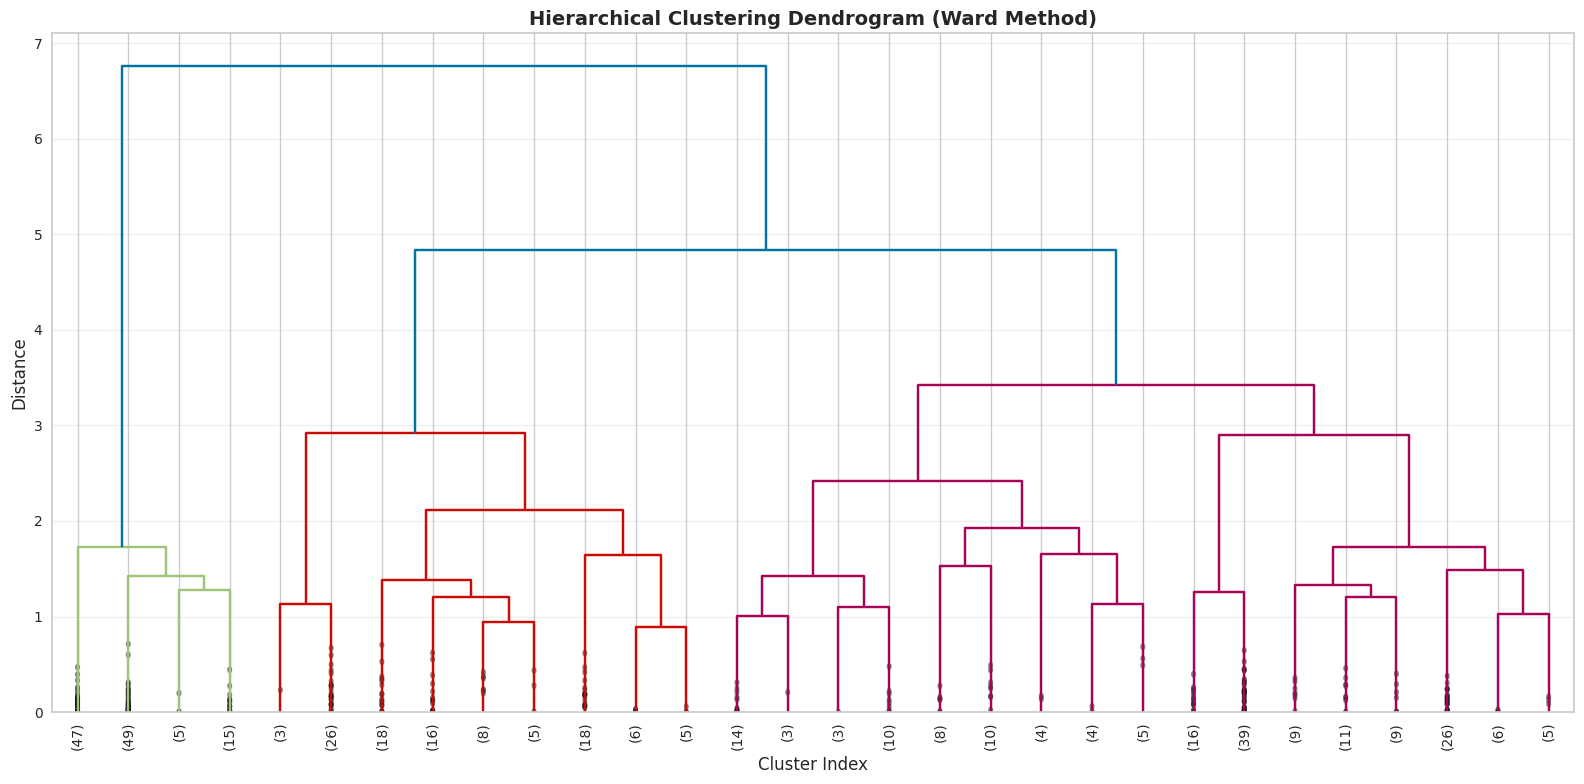


层次聚类完成！分为 6 个簇
各簇样本数分布:
hierarchical_cluster_id
1    116
2     29
3     76
4     61
5     55
6     66
Name: count, dtype: int64


In [10]:
# ===========================================================
# 层次聚类（Hierarchical Clustering）与树状图可视化
# ===========================================================
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

# 计算样本间的距离矩阵（使用余弦距离，适合高维向量）
print("计算距离矩阵...")
Y = pdist(X, metric='cosine')

# 执行层次聚类（使用 Ward 方法最小化簇内方差）
print("执行层次聚类...")
Z = hierarchy.linkage(Y, method='ward')

# 绘制树状图（Dendrogram）
fig, ax = plt.subplots(figsize=(16, 8))
hierarchy.dendrogram(
    Z,
    truncate_mode='lastp',  # 只显示最后 p 个合并
    p=30,  # 显示最后 30 个合并节点
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,  # 显示被压缩的簇
    ax=ax,
    color_threshold=0.7 * max(Z[:, 2])  # 颜色阈值设为最大距离的 70%
)
ax.set_xlabel('Cluster Index', fontsize=12)
ax.set_ylabel('Distance', fontsize=12)
ax.set_title('Hierarchical Clustering Dendrogram (Ward Method)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 基于树状图切割获取聚类标签（自动选择簇数）
# 可以通过设置 distance_threshold 或指定 n_clusters
hierarchical_k = optimal_k  # 使用 KMeans 肘点法推荐的簇数，也可以手动调整
hierarchical_labels = hierarchy.fcluster(Z, t=hierarchical_k, criterion='maxclust')

# 将层次聚类标签添加到 dataframe（避免与 KMeans 的 cluster_id 冲突）
df['hierarchical_cluster_id'] = hierarchical_labels

print(f"\n层次聚类完成！分为 {len(np.unique(hierarchical_labels))} 个簇")
print(f"各簇样本数分布:")
print(df['hierarchical_cluster_id'].value_counts().sort_index())


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

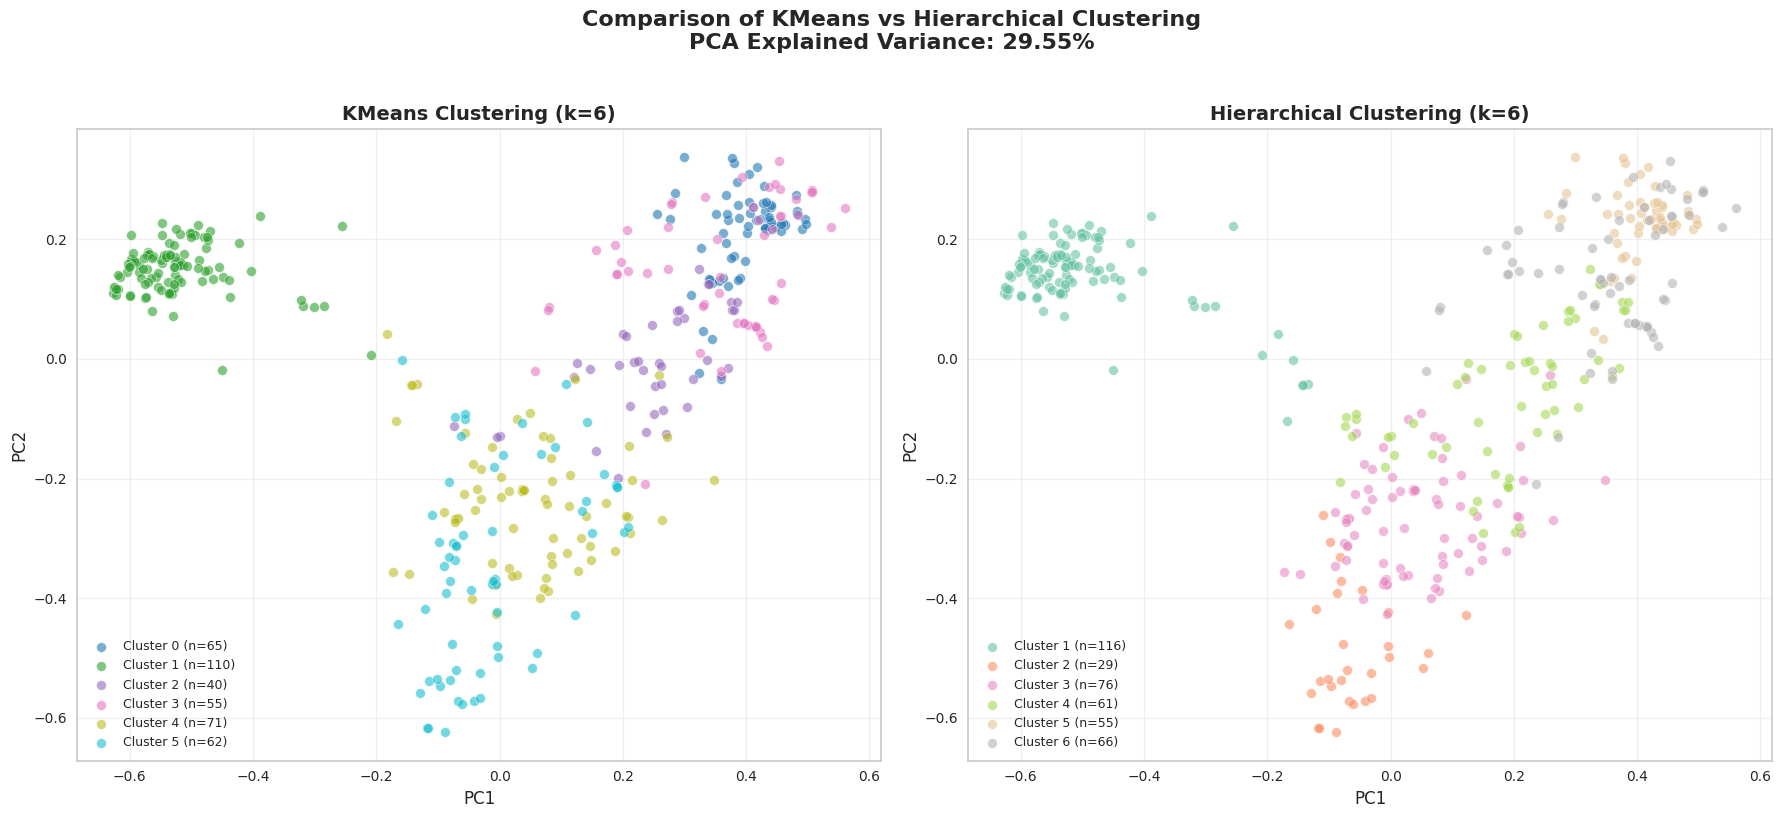


PCA 解释方差比例: PC1=20.94%, PC2=8.61%
总解释方差: 29.55%

KMeans 与层次聚类的 Adjusted Rand Index: 0.7960
（ARI = 1.0 表示完全一致，0.0 表示随机，负值表示比随机还差）


In [11]:
# ===========================================================
# 可视化层次聚类结果（PCA 2D）
# ===========================================================
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 使用 PCA 将高维向量降维到 2D
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

# 创建图形
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 左图：KMeans 聚类结果
ax1 = axes[0]
kmeans_labels = df['cluster_id'].values
unique_kmeans = sorted(df['cluster_id'].unique())
colors_kmeans = plt.cm.tab10(np.linspace(0, 1, len(unique_kmeans)))

for i, cluster_id in enumerate(unique_kmeans):
    mask = kmeans_labels == cluster_id
    cluster_points = X_2d[mask]
    ax1.scatter(
        cluster_points[:, 0], 
        cluster_points[:, 1],
        c=[colors_kmeans[i]], 
        label=f'Cluster {cluster_id} (n={len(cluster_points)})',
        alpha=0.6,
        s=50,
        edgecolors='white',
        linewidth=0.5
    )

ax1.set_xlabel('PC1', fontsize=12)
ax1.set_ylabel('PC2', fontsize=12)
ax1.set_title(f'KMeans Clustering (k={optimal_k})', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# 右图：层次聚类结果
ax2 = axes[1]
hier_labels = df['hierarchical_cluster_id'].values
unique_hier = sorted(df['hierarchical_cluster_id'].unique())
colors_hier = plt.cm.Set2(np.linspace(0, 1, len(unique_hier)))

for i, cluster_id in enumerate(unique_hier):
    mask = hier_labels == cluster_id
    cluster_points = X_2d[mask]
    ax2.scatter(
        cluster_points[:, 0], 
        cluster_points[:, 1],
        c=[colors_hier[i]], 
        label=f'Cluster {cluster_id} (n={len(cluster_points)})',
        alpha=0.6,
        s=50,
        edgecolors='white',
        linewidth=0.5
    )

ax2.set_xlabel('PC1', fontsize=12)
ax2.set_ylabel('PC2', fontsize=12)
ax2.set_title(f'Hierarchical Clustering (k={len(unique_hier)})', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle(
    f'Comparison of KMeans vs Hierarchical Clustering\n'
    f'PCA Explained Variance: {pca.explained_variance_ratio_.sum():.2%}',
    fontsize=16,
    fontweight='bold',
    y=1.02
)
plt.tight_layout()
plt.show()

print(f"\nPCA 解释方差比例: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")
print(f"总解释方差: {pca.explained_variance_ratio_.sum():.2%}")

# 比较两种聚类的一致性
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(kmeans_labels, hier_labels)
print(f"\nKMeans 与层次聚类的 Adjusted Rand Index: {ari:.4f}")
print(f"（ARI = 1.0 表示完全一致，0.0 表示随机，负值表示比随机还差）")
